# Aplicação do modelo XGboost

A base estudada é de propensão a compra de carros. O objetivo é criar um modelo XGboost para a previsão de compra de carros.

### Configurações iniciais

In [99]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [100]:
df = pd.read_csv('CARRO_CLIENTES.csv')
df.drop(columns=['User ID'], inplace=True)
df.head(3)

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0


### Pré-processamento dos dados 
Como mostram os dados a seguir, a base não tem dados nulos, os tipos estão coerentes, não há valores inaprópriados ou com erros de digitação.

In [101]:
print(f'Tamanho: {df.shape}\n\nNulos:\n{df.isnull().sum()}\n\n')
print(df.info())


Tamanho: (1000, 4)

Nulos:
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Gender        1000 non-null   object
 1   Age           1000 non-null   int64 
 2   AnnualSalary  1000 non-null   int64 
 3   Purchased     1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB
None


In [102]:
print('Valores Únicos por coluna categorica ou binária:\n')
print(df['Gender'].unique())
print(df["Purchased"].unique())

Valores Únicos por coluna categorica ou binária:

['Male' 'Female']
[0 1]


#### Outlieres

Como é possível verificar nos dados e gráficos abaixo, não há valor fora do limte para nenhum campo.

In [103]:
df.describe()

,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


In [ ]:

for campo in df.columns:
    
    fig = make_subplots(rows=1,
                    cols=2,
                    subplot_titles=[f'Histograma de {campo}',
                                        f'Box Plot de {campo}'])
    fig.add_trace(
    px.histogram(df,
                    x=campo, 
                    histnorm="percent", 
                    nbins=100).data[0],
    row=1, col=1
    )

    fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )

    
    if df[campo].dtype.kind in 'biufc':
        # IQR
        q1 = df[campo].quantile(0.25)
        q3 = df[campo].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        fig.add_hline(y=upper_bound, 
                line_dash="dash", 
                line_color="red", 
                row=1, col=2)
        fig.add_vline(x=upper_bound,
                line_dash="dash",
                line_color="red",
                row=1, col=1)
            

    fig.update_layout(title_text=f'{campo}', 
                    showlegend=False)
    fig.show()


#### Tratamento das variáveis categóricas

In [ ]:
label_encoder = LabelEncoder()
categorias = ['Gender']
for categoria in categorias:
    df[categoria] = label_encoder.fit_transform(df[categoria])
print(df.head())

   Gender  Age  AnnualSalary  Purchased
0       1   35         20000          0
1       1   40         43500          0
2       1   49         74000          0
3       1   40        107500          1
4       1   25         79000          0


### Matriz de Correlação

A matriz de correalação da base mostra a correlação entre as variáveis. Abaixo é possível ver a matriz completa. Para fins de análise, a matriz foi dividida em duas: a primeira com as corelações 'fortes', com módulo acima de 0.5, e fracas, as restantes. Os valores igual a 1 foram excluídos pois representam informação redundante.

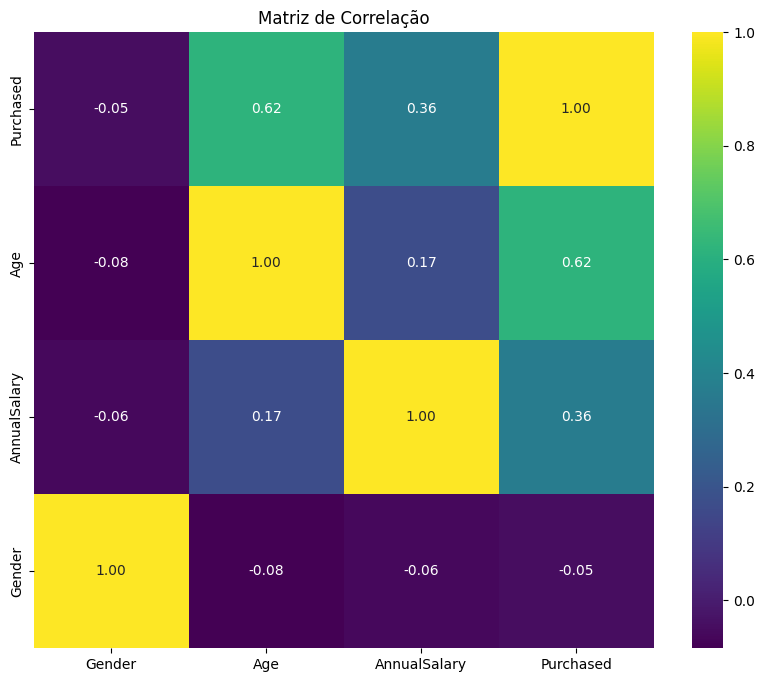

In [ ]:
alvo = 'Purchased'
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix.sort_values(by=alvo, ascending=False, inplace=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

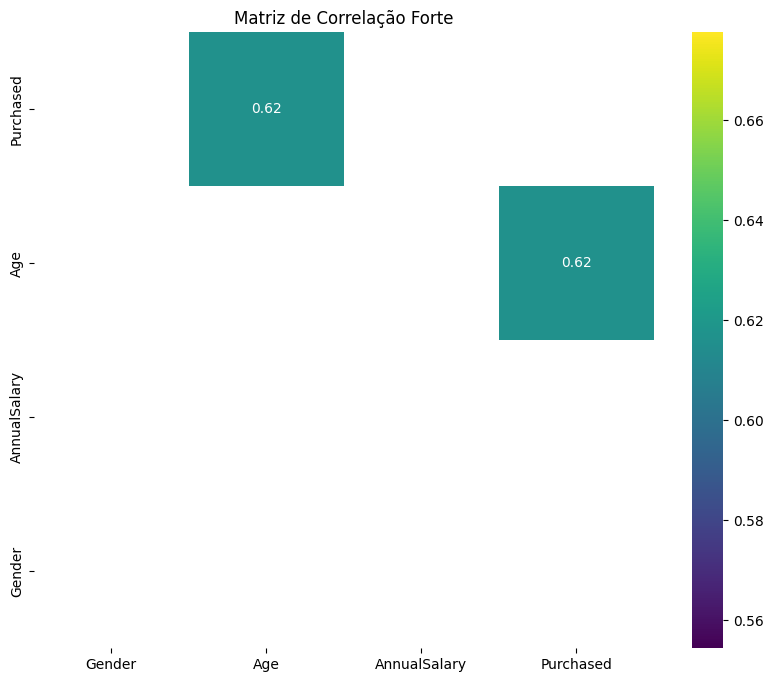

In [ ]:

#$ Mapa Apenas das Correlações Fortes
plt.figure(figsize=(10, 8))
correlation_matrix_strong = correlation_matrix[(correlation_matrix.abs() >= 0.5) & (correlation_matrix != 1)]
sns.heatmap(correlation_matrix_strong, annot=True, cmap='viridis', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação Forte')
plt.show()

A correlação mais forte, e única superior a 0,5, é a relação entre compra (Purchased) e idade (Age). A relação não é muito forte, o que indica que, apesar da forte influência, as outras variáveis podem também influenciar, mesmo que pouco.

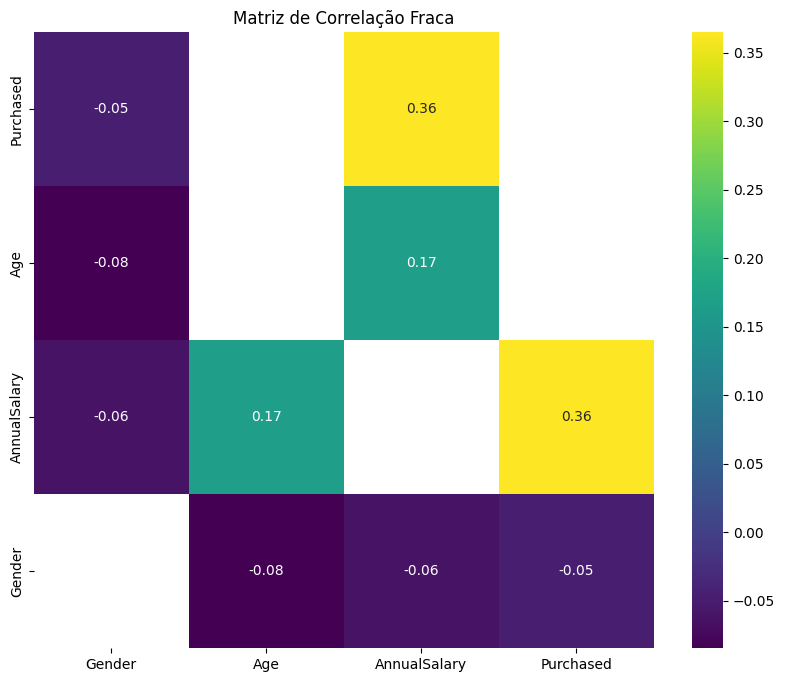

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix_strong = correlation_matrix[correlation_matrix.abs() < 0.5]
sns.heatmap(correlation_matrix_strong, annot=True, cmap='viridis', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação Fraca')
plt.show()

Dentre as relações mais fracas, todas as relações com gênero são fracas. Isso indica que essa variável não influencia na probabilidade de compra. Chama atenção a relação entre salário anual (AnnualSalary) e idade: já que a última foi identificada como uma forte influência para compra, sua relação com salário anual é carregada para a probabilidade de compra. Essa influencia pode ser vista na relação entre salário anual e compra, que, ainda que pequena, é a segunda maior.

A forte relação com idade pode indicar que a chance de compra está relacionada a necessidades ou mudanças de comportamento comuns de determinadas idades, mas a relação com salário anual acrescenta que a compra vai depender das ocndições financeiras do cliente. 

### Separação da base em X e Y e de treino e teste.

In [ ]:
X = df.drop('Purchased', axis = 1)
Y = df['Purchased']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Treino do modelo Xgboost 
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [ ]:
# model_xgboost = xgb.XGBClassifier()
# model_xgboost.objective
model_xgboost_hyper = xgb.XGBClassifier(
    max_depth=5,                  # Profundidade máxima da árvore
    n_estimators=100,             # Número de árvores a serem construídas
    eta = 0.7,                    # Step size shrinkage used in update to prevent overfitting.
    sampling_method = 'subsample'   # subsample >= 0.5 for good results - The method to use to sample the training instances.
)
model_xgboost_hyper = xgb.XGBClassifier().fit(X_train, Y_train)

In [ ]:
model_xgboost_hyper = xgb.XGBClassifier().fit(X_train, Y_train)

### Previsões para a base de teste e asprobabilidades das previsões

In [ ]:
Y_pred = model_xgboost_hyper.predict(X_test)           # Previsões das classes
Y_pred_prob = model_xgboost_hyper.predict_proba(X_test)  # Probabilidades de cada classe

In [ ]:

print('\nProbabilidade da amostra pertencer a cada classe listada:\n')
for i in range(0, len(Y_pred_prob)):
    print(f'Classe {i}: {Y_pred_prob[i][0]*100:.2f}%')


Probabilidade da amostra pertencer a cada classe listada:

Classe 0: 92.69%
Classe 1: 9.71%
Classe 2: 99.99%
Classe 3: 88.52%
Classe 4: 31.77%
Classe 5: 0.32%
Classe 6: 0.04%
Classe 7: 99.98%
Classe 8: 99.91%
Classe 9: 99.94%
Classe 10: 98.96%
Classe 11: 99.99%
Classe 12: 95.01%
Classe 13: 99.97%
Classe 14: 0.19%
Classe 15: 2.63%
Classe 16: 73.11%
Classe 17: 8.55%
Classe 18: 1.54%
Classe 19: 99.95%
Classe 20: 99.96%
Classe 21: 0.08%
Classe 22: 0.26%
Classe 23: 99.99%
Classe 24: 0.37%
Classe 25: 96.97%
Classe 26: 0.33%
Classe 27: 0.16%
Classe 28: 99.90%
Classe 29: 93.33%
Classe 30: 96.53%
Classe 31: 1.00%
Classe 32: 0.62%
Classe 33: 87.99%
Classe 34: 0.21%
Classe 35: 99.92%
Classe 36: 99.99%
Classe 37: 99.90%
Classe 38: 98.81%
Classe 39: 0.11%
Classe 40: 55.63%
Classe 41: 91.49%
Classe 42: 5.44%
Classe 43: 99.96%
Classe 44: 5.15%
Classe 45: 46.96%
Classe 46: 99.97%
Classe 47: 19.03%
Classe 48: 58.36%
Classe 49: 63.51%
Classe 50: 0.07%
Classe 51: 0.06%
Classe 52: 99.94%
Classe 53: 0.24%

### Avaliação do modelo

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

Acurácia: 0.9
Relatório de Classificação:
              precision    recall  f1-score   support

      Female       0.90      0.93      0.91       112
        Male       0.90      0.86      0.88        88

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200

Matriz de Confusão:


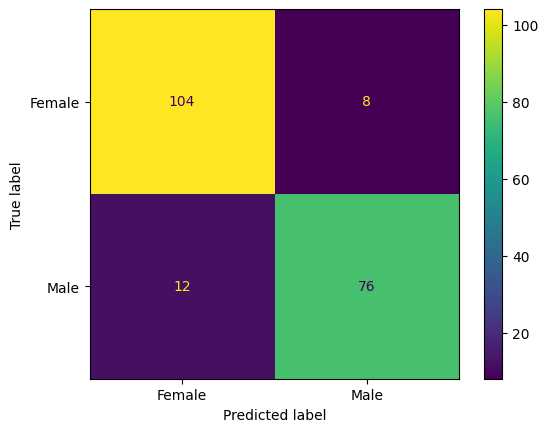

In [115]:
# Transformação das previsões e os rótulos de volta para os rótulos originais
Y_pred_original = label_encoder.inverse_transform(Y_pred)
Y_test_original = label_encoder.inverse_transform(Y_test)
accuracy = accuracy_score(Y_test_original, Y_pred_original)
report = classification_report(Y_test_original, Y_pred_original)
conf_matrix = confusion_matrix(Y_test_original, Y_pred_original)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(ConfusionMatrixDisplay.from_predictions(Y_test_original, Y_pred_original))

O modelo apresentou bons resultados, com números próximos a 1. EM valores absolutos, o modelo errou pouquíssemas previsões de compra (valores em roxo), com um valor menor de previsões de possíveis compradores do que de não compradores.

### Lista de importância das variáveis explicativas (feature importance)

In [ ]:
# features (x) mais importantes
importances = model_xgboost_hyper.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para um DataFrame
importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)
num_features = 2 # baseada na análise de correlação
top_features = importance_df.head(num_features)['Feature'].tolist()

        Feature  Importance
1           Age    1.851948
2  AnnualSalary    1.107248
0        Gender    0.496729


O resultado do modelo está de acordo com as análises da matriz de correlação. Ou seja, o cálculo de importância feita pelo modelo para cada variável explicativa é coerente com o esperado.